### 1- Table EVENTS


#### Variables de la table `events` — Dictionnaire complet

##### Temporelles
| Variable | Type | Description |
|---|---|---|
| `SQLDATE` | int64 | Date de l'événement (YYYYMMDD) |
| `DATEADDED` | int64 | Date d'ajout dans GDELT (YYYYMMDDHHmmSS) — peut différer de SQLDATE |

---

##### Structure de l'événement
| Variable | Type | Description |
|---|---|---|
| `IsRootEvent` | int64 | 1 = événement racine (article original), 0 = événement dérivé (reprise) |
| `EventCode` | int64 | Code CAMEO précis de l'action (ex: 190 = usage de la force) |
| `EventBaseCode` | int64 | Version simplifiée de EventCode (2 chiffres) |
| `EventRootCode` | int64 | Version racine de EventCode (1-2 chiffres) — 20 catégories max |
| `QuadClass` | int64 | Catégorie large : 1=Déclaration, 2=Coopération, 3=Conflit verbal, 4=Conflit matériel |

---

##### Acteur 1 — L'initiateur de l'action
| Variable | Type | Description |
|---|---|---|
| `Actor1Name` | object | Nom textuel de l'acteur 1 (ex: "GOVERNMENT", "POLICE") |
| `Actor1CountryCode` | object | Code CAMEO du pays de l'acteur 1 (ex: BEN = Bénin) |
| `Actor1Type1Code` | object | Type de l'acteur 1 (ex: GOV=gouvernement, MIL=militaire, LEG=législatif) |

---

##### Acteur 2 — La cible ou le second acteur
| Variable | Type | Description |
|---|---|---|
| `Actor2Name` | object | Nom textuel de l'acteur 2 |
| `Actor2CountryCode` | object | Code CAMEO du pays de l'acteur 2 |
| `Actor2Type1Code` | object | Type de l'acteur 2 |

---

##### Scores analytiques
| Variable | Type | Interprétation |
|---|---|---|
| `GoldsteinScale` | float64 | Impact théorique sur la stabilité nationale. [-10 = très déstabilisateur, +10 = très stabilisateur] |
| `AvgTone` | float64 | Ton émotionnel moyen de l'article. [Négatif = pessimiste, Positif = optimiste] |

---

##### Métriques de couverture médiatique
| Variable | Type | Description |
|---|---|---|
| `NumMentions` | int64 | Nombre de fois que l'événement est mentionné dans tous les articles |
| `NumSources` | int64 | Nombre de sources distinctes ayant couvert l'événement |
| `NumArticles` | int64 | Nombre d'articles distincts couvrant l'événement |

---

##### Géolocalisation de l'action
| Variable | Type | Description |
|---|---|---|
| `ActionGeo_Type` | int64 | Précision géo : 1=Pays, 2=Région, 3=Ville, 4=Lieu précis |
| `ActionGeo_FullName` | object | Nom complet du lieu (ex: "Cotonou, Littoral, Benin") |
| `ActionGeo_CountryCode` | object | Code FIPS du pays (BN = Bénin) |
| `ActionGeo_Lat` | float64 | Latitude du lieu de l'action |
| `ActionGeo_Long` | float64 | Longitude du lieu de l'action |
| `ActionGeo_FeatureID` | object | Identifiant unique du lieu dans la base GeoNames |

---

##### Source
| Variable | Type | Description |
|---|---|---|
| `SOURCEURL` | object | URL de l'article source ayant généré cet événement |


#### 1-1) Niveau 1 d'analyse

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/data/raw/benin_events.csv')

# ── 1. DIMENSIONS ──
print("═" * 50)
print(f"  Lignes    : {df.shape[0]:,}")
print(f"  Colonnes  : {df.shape[1]}")
print("═" * 50)

# ── 2. TYPES ET VALEURS MANQUANTES ──
print("\n── Types & Valeurs manquantes ──")
resume = pd.DataFrame({
    'type'       : df.dtypes,
    'manquants'  : df.isnull().sum(),
    'pct_manquant': (df.isnull().sum() / len(df) * 100).round(2),
    'unique'     : df.nunique()
})
display(resume)

# ── 3. DOUBLONS ──
doublons = df.duplicated().sum()
print(f"\n── Doublons : {doublons} ({doublons/len(df)*100:.2f}%)")

# ── 4. PLAGE TEMPORELLE ──
print(f"\n── Plage temporelle ──")
print(f"  Premier événement : {df['SQLDATE'].min()}")
print(f"  Dernier événement : {df['SQLDATE'].max()}")
print(f"  Mois couverts     : {df['SQLDATE'].astype(str).str[:6].nunique()}")

# ── 5. COLONNES CRITIQUES ──
print(f"\n── Aperçu colonnes clés ──")
cols_cles = ['GoldsteinScale', 'AvgTone', 'NumMentions', 'NumArticles', 'QuadClass']
display(df[cols_cles].describe().round(3))

══════════════════════════════════════════════════
  Lignes    : 31,504
  Colonnes  : 25
══════════════════════════════════════════════════

── Types & Valeurs manquantes ──


,type,manquants,pct_manquant,unique
SQLDATE,int64,0,0.00,352
DATEADDED,int64,0,0.00,7303
QuadClass,int64,0,0.00,4
IsRootEvent,int64,0,0.00,2
Actor1Name,object,2545,8.08,870
Actor1CountryCode,object,12713,40.35,140
Actor1Type1Code,object,18857,59.86,28
Actor2Name,object,7988,25.36,761
Actor2CountryCode,object,15268,48.46,134
Actor2Type1Code,object,22316,70.84,29



── Doublons : 756 (2.40%)

── Plage temporelle ──
  Premier événement : 20250101
  Dernier événement : 20251231
  Mois couverts     : 12

── Aperçu colonnes clés ──


,GoldsteinScale,AvgTone,NumMentions,NumArticles,QuadClass
count,31504.000,31504.000,31504.000,31504.000,31504.000
mean,0.683,-1.369,5.439,5.344,1.747
std,4.624,4.484,3.997,3.771,1.118
min,-10.000,-18.519,1.000,1.000,1.000
25%,-2.000,-4.525,2.000,2.000,1.000
50%,1.900,-1.297,4.000,4.000,1.000
75%,3.400,1.872,10.000,10.000,3.000
max,10.000,19.481,48.000,48.000,4.000


  

#### Interprétation du Niveau 1

##### ✅ Ce qui est rassurant

```
12 mois couverts complets — janvier à décembre 2025 ✅
Colonnes analytiques centrales : 0 manquant ✅
GoldsteinScale : [-10, +10] — plage théorique respectée ✅
AvgTone : [-18.5, +19.5] — valeurs cohérentes ✅
```

---

##### ⚠️ Ce qui mérite attention

**1 — Les doublons (756 soit 2.40%)**
```
Cause probable : un même événement capturé 
par plusieurs sources médias différentes
Action : supprimer avant toute analyse
```

**2 — Acteurs très lacunaires**
```
Actor1Type1Code  →  59.86% manquant
Actor2Type1Code  →  70.84% manquant
Actor1CountryCode → 40.35% manquant
Actor2CountryCode → 48.46% manquant
```
C'est normal dans GDELT — beaucoup d'articles ne permettent pas d'identifier clairement les acteurs. Ces colonnes seront **utilisables pour les analyses de réseau** mais pas comme base de comptage fiable.

**3 — ActionGeo_FullName : 37 manquants (0.12%)**
```
Négligeable — on peut supprimer ces lignes sans impact
```

---

##### 📊 Ce que les statistiques descriptives révèlent déjà

**GoldsteinScale — moyenne 0.683**
```
Légèrement positif sur le papier
Mais médiane à 1.9 et Q1 à -2.0
→ Distribution asymétrique avec une queue négative
→ Les événements négatifs sont moins fréquents mais plus intenses
```

**AvgTone — moyenne -1.369**
```
Globalement négatif — la presse parle du Bénin 
dans un registre légèrement pessimiste
Mais médiane à -1.297 → distribution relativement symétrique
```

**QuadClass — médiane à 1, Q3 à 3**
```
50% des événements sont de type 1 (déclarations verbales)
25% sont des conflits (type 3 ou 4)
→ Le Bénin est majoritairement un pays de diplomatie/discours
```


In [2]:
# 1. Supprimer les doublons
df = df.drop_duplicates()
print(f"Après suppression doublons : {len(df):,} lignes")

# 2. Supprimer les 37 lignes sans géolocalisation
df = df.dropna(subset=['ActionGeo_FullName'])
print(f"Après suppression sans géo : {len(df):,} lignes")

print(f"\nPerte totale : {31504 - len(df):,} lignes ({(31504 - len(df))/31504*100:.2f}%)")

Après suppression doublons : 30,748 lignes
Après suppression sans géo : 30,711 lignes

Perte totale : 793 lignes (2.52%)


In [3]:
df.to_csv('/content/data/raw/benin_events_clean.csv', index=False)
print("✅ benin_events_clean.csv sauvegardé — 30 711 lignes")

✅ benin_events_clean.csv sauvegardé — 30 711 lignes


#### 1-2) Niveau 2 d'analyse

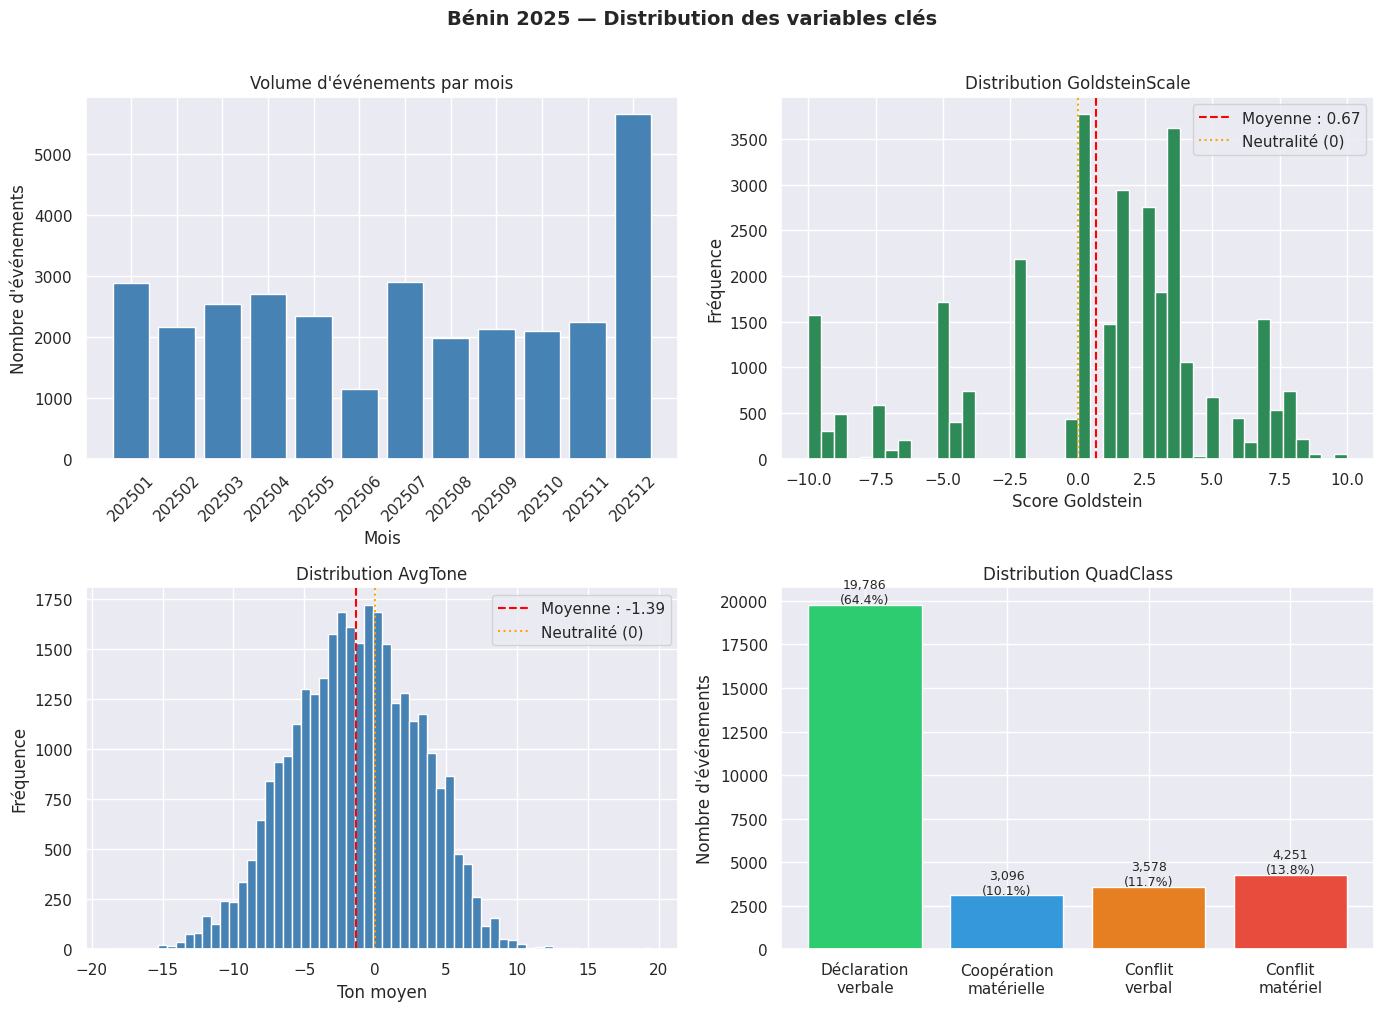

✅ Graphiques sauvegardés


In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bénin 2025 — Distribution des variables clés', fontsize=14, fontweight='bold', y=1.01)

# ── 1. Volume mensuel ──
df['mois'] = df['SQLDATE'].astype(str).str[:6]
volume_mensuel = df.groupby('mois').size().reset_index(name='nb_evenements')

axes[0,0].bar(volume_mensuel['mois'], volume_mensuel['nb_evenements'], color='steelblue')
axes[0,0].set_title("Volume d'événements par mois")
axes[0,0].set_xlabel("Mois")
axes[0,0].set_ylabel("Nombre d'événements")
axes[0,0].tick_params(axis='x', rotation=45)

# ── 2. Distribution GoldsteinScale ──
axes[0,1].hist(df['GoldsteinScale'], bins=42, color='seagreen', edgecolor='white')
axes[0,1].axvline(df['GoldsteinScale'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['GoldsteinScale'].mean():.2f}")
axes[0,1].axvline(0, color='orange', linestyle=':', label="Neutralité (0)")
axes[0,1].set_title("Distribution GoldsteinScale")
axes[0,1].set_xlabel("Score Goldstein")
axes[0,1].set_ylabel("Fréquence")
axes[0,1].legend()

# ── 3. Distribution AvgTone ──
axes[1,0].hist(df['AvgTone'], bins=60, color='steelblue', edgecolor='white')
axes[1,0].axvline(df['AvgTone'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['AvgTone'].mean():.2f}")
axes[1,0].axvline(0, color='orange', linestyle=':', label="Neutralité (0)")
axes[1,0].set_title("Distribution AvgTone")
axes[1,0].set_xlabel("Ton moyen")
axes[1,0].set_ylabel("Fréquence")
axes[1,0].legend()

# ── 4. Distribution QuadClass ──
quad_labels = {1: 'Déclaration\nverbale', 2: 'Coopération\nmatérielle', 3: 'Conflit\nverbal', 4: 'Conflit\nmatériel'}
quad_counts = df['QuadClass'].value_counts().sort_index()
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

axes[1,1].bar([quad_labels[i] for i in quad_counts.index], quad_counts.values, color=colors)
axes[1,1].set_title("Distribution QuadClass")
axes[1,1].set_ylabel("Nombre d'événements")
for i, v in enumerate(quad_counts.values):
    axes[1,1].text(i, v + 100, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/data/raw/niveau2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques sauvegardés")

#### Lecture des 4 graphiques

##### Volume mensuel — Le signal le plus fort
```
Juin 2025    : ~1 100 événements  ← creux anormal
Décembre 2025: ~5 700 événements  ← pic anormal
```
Ces deux anomalies méritent une investigation au Niveau 3. Un creux en juin et un pic en décembre ne sont pas du bruit — quelque chose s'est passé.

---

##### GoldsteinScale — Distribution bimodale révélatrice
```
Deux masses distinctes :
  Gauche  : [-10, -2]  → événements déstabilisateurs
  Droite  : [+1, +7]   → événements coopératifs/stables
  Moyenne : +0.67      → légèrement positif mais trompeur
```
La moyenne positive cache une **polarisation réelle** — le Bénin génère à la fois des événements très positifs et très négatifs. Ce n'est pas un pays "neutre", c'est un pays **divisé dans sa couverture**.

---

##### AvgTone — Distribution quasi-normale
```
Centrée sur -1.39 → légèrement négatif
Symétrique → pas de queue extrême dominante
```
La presse parle du Bénin dans un registre légèrement pessimiste mais **sans dramatisation**. C'est cohérent avec l'image d'un pays stable mais sous surveillance.

---

##### QuadClass — Le chiffre qui interpelle
```
Déclaration verbale  : 64.4%  → normal
Coopération          : 10.1%  → faible
Conflit verbal       : 11.7%  ↗
Conflit matériel     : 13.8%  ↗ ← signal fort
```
**25.5% des événements sont conflictuels** — 1 événement sur 4. Pour un pays présenté comme "îlot de stabilité", c'est une donnée à confronter directement à la baseline régionale au Niveau 4.

---

##### Ce que le Niveau 2 dit déjà sur la question centrale

> Le Bénin n'est pas un pays au profil plat. Le volume de décembre, la bimodalité de Goldstein, et 1 événement sur 4 de nature conflictuelle sont trois signaux qui questionnent déjà le mythe de la stabilité.


### 1-3) Niveau 3 d'analyse

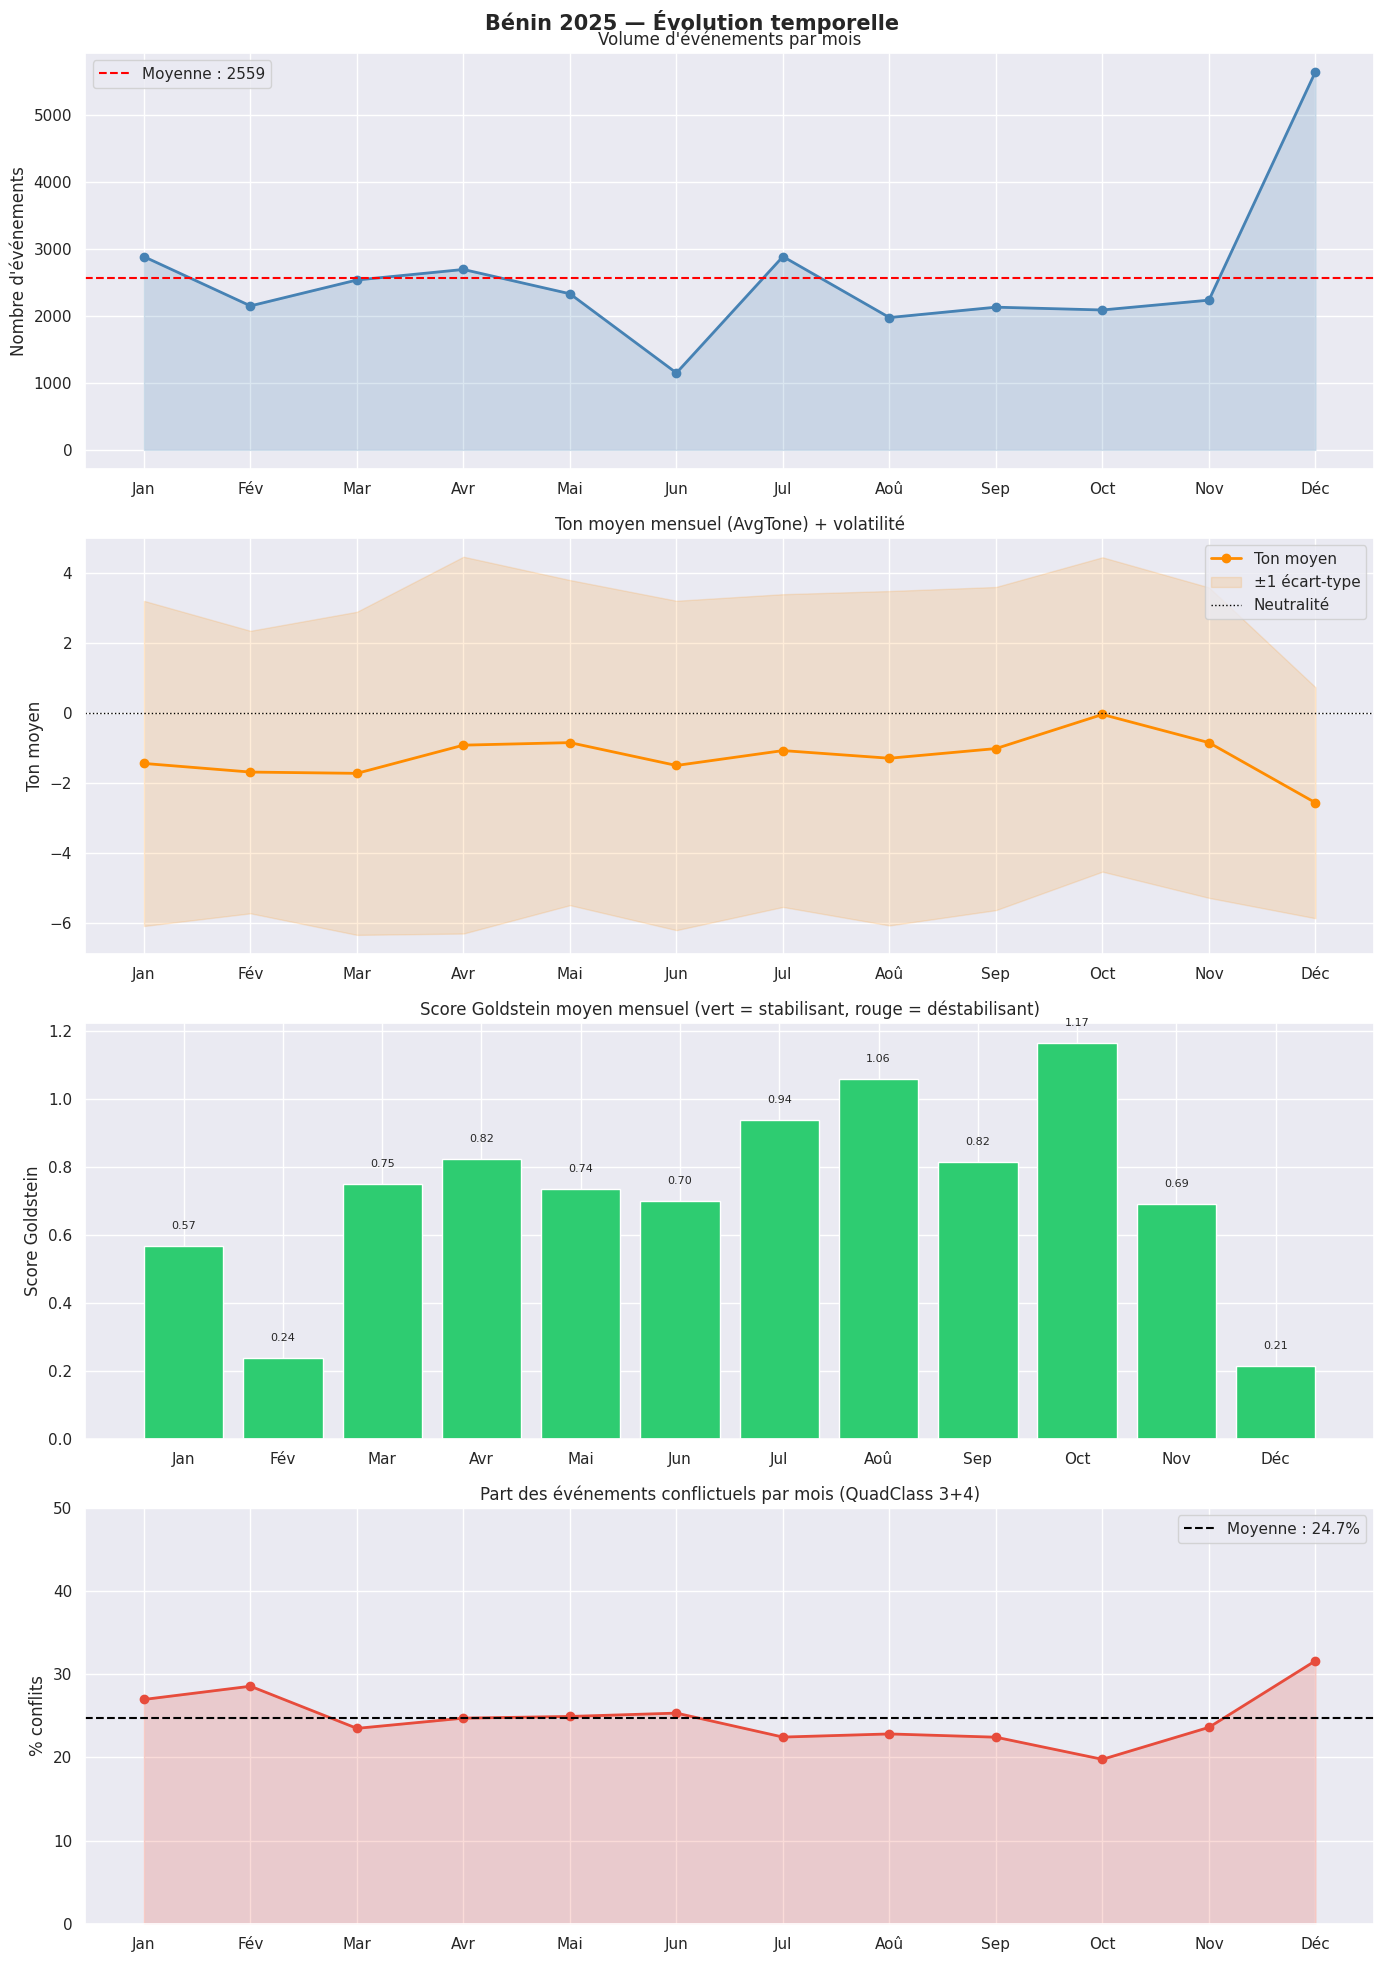

✅ Graphiques sauvegardés


In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style='darkgrid')
df['mois'] = df['SQLDATE'].astype(str).str[:6]

# ── Agrégation mensuelle ──
mensuel = df.groupby('mois').agg(
    nb_evenements   = ('SQLDATE', 'count'),
    ton_moyen       = ('AvgTone', 'mean'),
    ton_volatilite  = ('AvgTone', 'std'),
    goldstein_moyen = ('GoldsteinScale', 'mean'),
    pct_conflits    = ('QuadClass', lambda x: (x.isin([3,4])).mean() * 100)
).reset_index()

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc']

fig, axes = plt.subplots(4, 1, figsize=(14, 20))
fig.suptitle('Bénin 2025 — Évolution temporelle', fontsize=15, fontweight='bold')

# ── 1. Volume mensuel ──
axes[0].plot(mois_labels, mensuel['nb_evenements'], marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(mois_labels, mensuel['nb_evenements'], alpha=0.2, color='steelblue')
axes[0].axhline(mensuel['nb_evenements'].mean(), color='red', linestyle='--', label=f"Moyenne : {mensuel['nb_evenements'].mean():.0f}")
axes[0].set_title("Volume d'événements par mois")
axes[0].set_ylabel("Nombre d'événements")
axes[0].legend()

# ── 2. Évolution AvgTone + volatilité ──
axes[1].plot(mois_labels, mensuel['ton_moyen'], marker='o', color='darkorange', linewidth=2, label='Ton moyen')
axes[1].fill_between(
    mois_labels,
    mensuel['ton_moyen'] - mensuel['ton_volatilite'],
    mensuel['ton_moyen'] + mensuel['ton_volatilite'],
    alpha=0.15, color='darkorange', label='±1 écart-type'
)
axes[1].axhline(0, color='black', linestyle=':', linewidth=1, label='Neutralité')
axes[1].set_title("Ton moyen mensuel (AvgTone) + volatilité")
axes[1].set_ylabel("Ton moyen")
axes[1].legend()

# ── 3. Évolution GoldsteinScale ──
colors_gold = ['#e74c3c' if v < 0 else '#2ecc71' for v in mensuel['goldstein_moyen']]
axes[2].bar(mois_labels, mensuel['goldstein_moyen'], color=colors_gold)
axes[2].axhline(0, color='black', linestyle='-', linewidth=0.8)
axes[2].set_title("Score Goldstein moyen mensuel (vert = stabilisant, rouge = déstabilisant)")
axes[2].set_ylabel("Score Goldstein")
for i, v in enumerate(mensuel['goldstein_moyen']):
    axes[2].text(i, v + (0.05 if v >= 0 else -0.15), f'{v:.2f}', ha='center', fontsize=8)

# ── 4. Part des conflits ──
axes[3].plot(mois_labels, mensuel['pct_conflits'], marker='o', color='#e74c3c', linewidth=2)
axes[3].fill_between(mois_labels, mensuel['pct_conflits'], alpha=0.2, color='#e74c3c')
axes[3].axhline(mensuel['pct_conflits'].mean(), color='black', linestyle='--',
                label=f"Moyenne : {mensuel['pct_conflits'].mean():.1f}%")
axes[3].set_title("Part des événements conflictuels par mois (QuadClass 3+4)")
axes[3].set_ylabel("% conflits")
axes[3].set_ylim(0, 50)
axes[3].legend()

plt.tight_layout()
plt.savefig('/content/data/raw/niveau3_temporel.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques sauvegardés")

#### Lecture du Niveau 3 — Ce que les courbes racontent

##### Volume — Deux anomalies confirmées
```
Juin  : ~1 100 événements  ← creux à investiguer
Déc   : ~5 700 événements  ← pic à investiguer (2x la moyenne)
```
Ce n'est pas du bruit. Ces deux mois cassent la régularité du reste de l'année.

---

##### AvgTone — Signal paradoxal
```
Jan → Nov  : ton stable entre -1 et -0.5, volatilité constante
Octobre    : remonte presque à 0 ← moment le plus positif de l'année
Décembre   : chute brutale à -2.5 ← coïncide avec le pic de volume
```
**Le pic de couverture de décembre est associé à une dégradation du ton.** Ce n'est pas un pic d'événements positifs — c'est une crise médiatique.

---

##### GoldsteinScale — Le signal le plus rassurant
```
12 mois sur 12 dans le vert ← aucun mois déstabilisateur net
Trajectoire Jan→Oct : progression (+0.57 → +1.17)
Décembre   : chute à +0.21 ← toujours positif mais en forte baisse
```
Goldstein reste positif toute l'année mais la chute de décembre confirme la tension.

---

##### % Conflits — La tendance de fond inquiétante
```
Moyenne annuelle : 24.7% ← 1 événement sur 4 est conflictuel
Juin → Oct      : sous la moyenne (période relativement calme)
Décembre        : pic à ~31% ← plus fort taux de conflits de l'année
```

---

##### Synthèse — Ce que le Niveau 3 dit sur la question centrale

```
Le Bénin de 2025 n'est pas un pays en crise
mais ce n'est plus non plus un pays serein.

Trois signaux convergent en décembre :
  ↑ Volume de couverture × 2
  ↓ Ton le plus négatif de l'année
  ↑ Part de conflits la plus élevée

Quelque chose s'est passé en décembre 2025
que le Niveau 4 doit identifier.
```

##### Avant le Niveau 4 — Une requête ciblée sur décembre

In [6]:
# Identifier les événements dominants de décembre
dec = df[df['mois'] == '202512'].copy()

print(f"Décembre : {len(dec)} événements")
print(f"\nTop EventRootCode :")
print(dec['EventRootCode'].value_counts().head(10))
print(f"\nTop Acteurs :")
print(dec['Actor1Name'].value_counts().head(10))
print(f"\nTop lieux :")
print(dec['ActionGeo_FullName'].value_counts().head(10))

Décembre : 5646 événements

Top EventRootCode :
EventRootCode
4     992
1     808
5     679
2     493
11    469
19    340
17    257
7     238
15    226
8     211
Name: count, dtype: int64

Top Acteurs :
Actor1Name
BENIN         1516
NIGERIA        516
NIGERIAN       198
PRESIDENT      193
ECOWAS         179
AFRICA         166
GOVERNMENT     162
FRANCE         120
COTONOU        114
MILITARY       102
Name: count, dtype: int64

Top lieux :
ActionGeo_FullName
Benin                                              3855
Nigeria                                             284
Abuja, Abuja Federal Capital Territory, Nigeria     148
France                                              120
Porto-Novo, Qué, Benin                               97
Tchaourou, Benin (general), Benin                    84
Lagos, Lagos, Nigeria                                70
Bissau, Bissau, Guinea-Bissau                        60
Paris, France (general), France                      55
Tinubu, Lagos, Nigeria            

#### Décembre 2025 — Lecture complète post-coup d'État

##### Les EventRootCode racontent la chronologie de la crise

```
Code 19 (Violence de masse)    = 340  → L'événement lui-même : attaques, tirs, bombardements
Code 5  (Protester)            = 679  → Réactions populaires et condamnations
Code 11 (Désapprouver)         = 469  → Condamnations institutionnelles UA, CEDEAO, France
Code 17 (Contraindre)          = 257  → Déploiement militaire ECOWAS, intervention nigériane
Code 4  (Consulter)            = 992  → Concertations diplomatiques d'urgence post-coup
Code 1  (Déclaration)          = 808  → Communiqués officiels, prises de parole de Talon
```

La séquence est lisible : violence → condamnations → concertations → stabilisation.

---

##### Les acteurs racontent qui a géré la crise

```
BENIN     = 1516  → Acteur central — le pays sous pression
NIGERIA   =  516  → Intervenant militaire direct (bombardement Camp Togbin)
NIGERIAN  =  198  → Aviation nigériane opérationnelle sur le sol béninois
PRESIDENT =  193  → Talon qui reprend la parole pour rassurer
ECOWAS    =  179  → Déploiement de la force en attente
FRANCE    =  120  → Condamnation + protection des ressortissants
COTONOU   =  114  → Épicentre géographique des événements
MILITARY  =  102  → Les mutins et les forces loyalistes
```

**Ce qui frappe : le Nigeria est plus présent que la France.** C'est l'intervention régionale africaine qui a sauvé Talon — pas l'ancienne puissance coloniale.

---

##### Les lieux racontent la géographie de la crise

```
Bénin (général)     = 3855  → Couverture nationale massive
Nigeria             =  284  → Pays intervenant
Abuja               =  148  → Décision politique nigériane prise ici
France / Paris      =  175  → Réaction diplomatique occidentale
Porto-Novo          =   97  → Capitale institutionnelle en alerte
Tchaourou           =   84  → Nord Bénin — origine des griefs sécuritaires des mutins
Lagos / Tinubu      =  124  → Tinubu (président nigérian) = acteur décisionnel clé
```

**Tchaourou est le détail le plus révélateur.** Les mutins ont explicitement cité la dégradation sécuritaire du nord comme justification. Ce lieu dans les données valide que la crise du 7 décembre n'est pas isolée — elle est le produit d'une tension accumulée.

---

##### Synthèse en une lecture

> Décembre 2025 concentre à lui seul toute la tension analytique de ton projet. Le Bénin n'était pas en train de s'effondrer — il subissait une pression multidimensionnelle : jihadisme au nord, espace civique réduit, tensions régionales post-AES. Le coup du 7 décembre en est la cristallisation. GDELT l'a capturé dans ses trois dimensions : le volume (5 646 événements), le ton (le plus bas de l'année) et la structure (1 événement sur 3 de nature conflictuelle ou coercitive).

**Le mythe de la stabilité n'est pas mort en décembre 2025. Mais les données montrent qu'il était déjà fissuré bien avant.**


### 1-4) Niveau 4 d'analyse

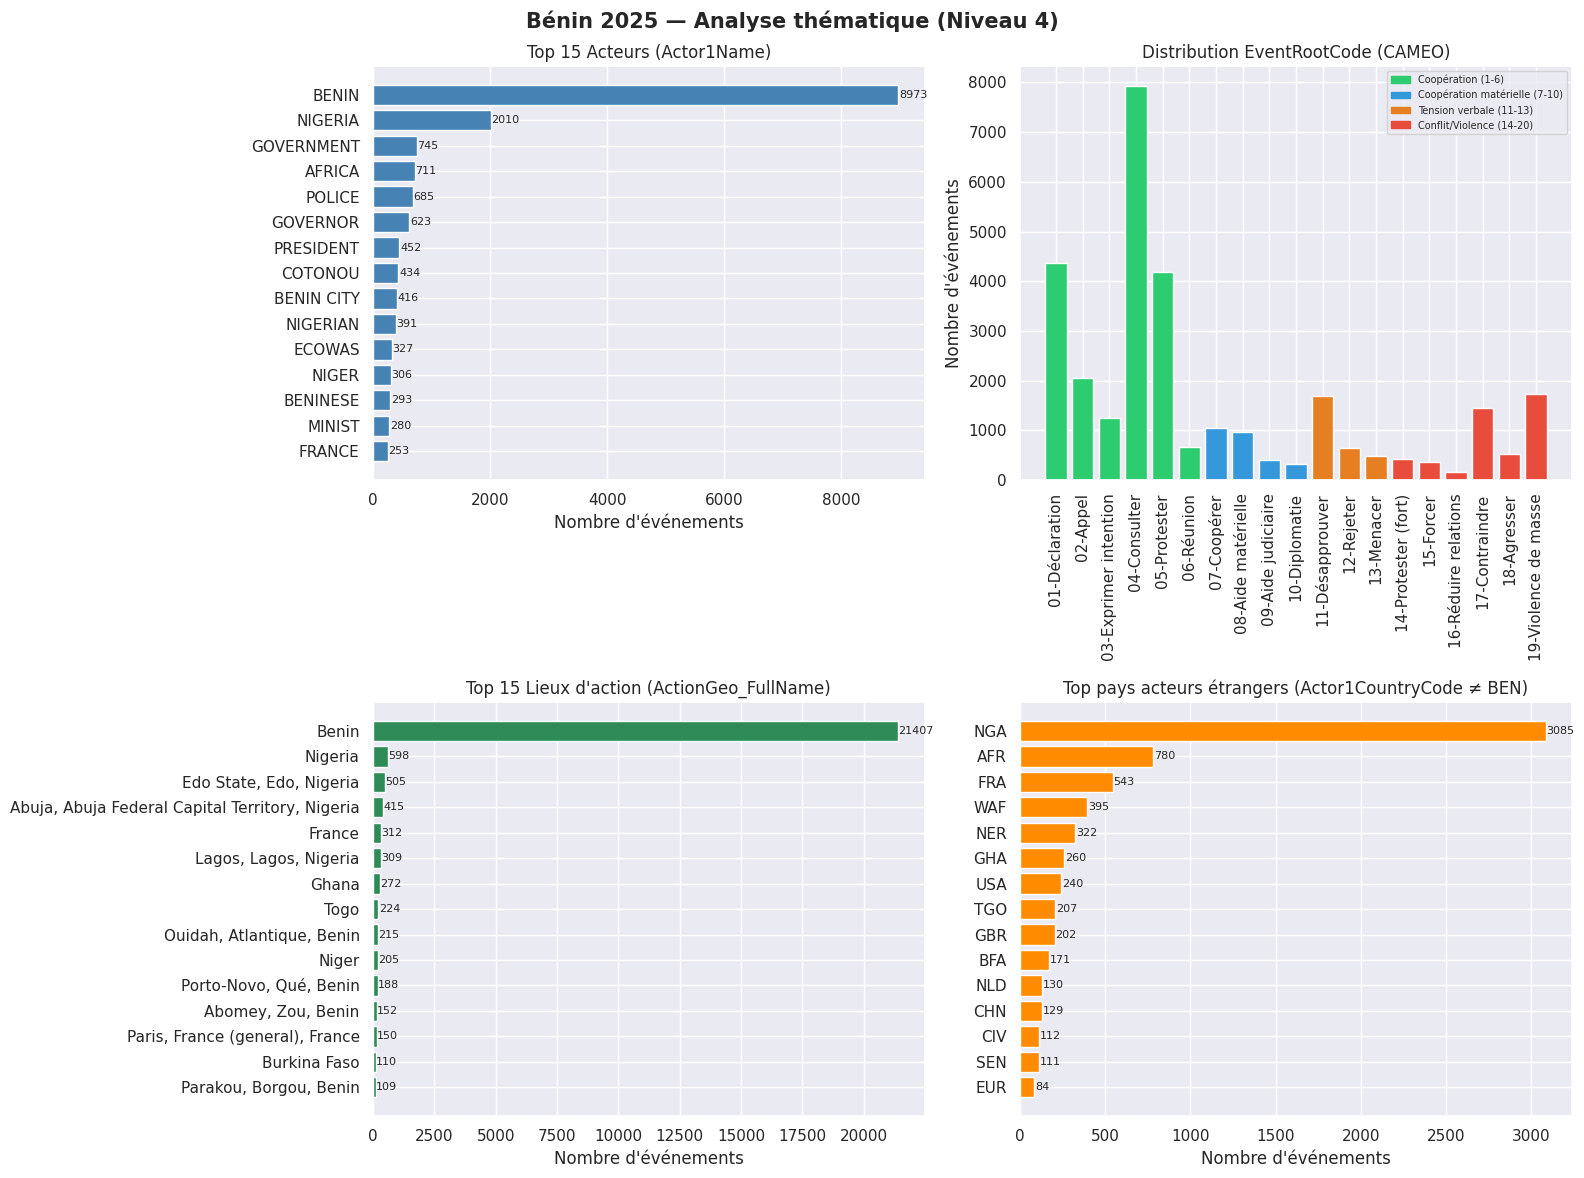

✅ Graphiques Niveau 4 sauvegardés


In [7]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_theme(style='darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Bénin 2025 — Analyse thématique (Niveau 4)', fontsize=15, fontweight='bold')

# ── 1. Top 15 Acteurs dominants ──
top_acteurs = df['Actor1Name'].value_counts().dropna().head(15)
axes[0,0].barh(top_acteurs.index[::-1], top_acteurs.values[::-1], color='steelblue')
axes[0,0].set_title("Top 15 Acteurs (Actor1Name)")
axes[0,0].set_xlabel("Nombre d'événements")
for i, v in enumerate(top_acteurs.values[::-1]):
    axes[0,0].text(v + 10, i, str(v), va='center', fontsize=8)

# ── 2. Distribution EventRootCode ──
cameo_labels = {
    1: '01-Déclaration', 2: '02-Appel', 3: '03-Exprimer intention',
    4: '04-Consulter', 5: '05-Protester', 6: '06-Réunion',
    7: '07-Coopérer', 8: '08-Aide matérielle', 9: '09-Aide judiciaire',
    10: '10-Diplomatie', 11: '11-Désapprouver', 12: '12-Rejeter',
    13: '13-Menacer', 14: '14-Protester (fort)', 15: '15-Forcer',
    16: '16-Réduire relations', 17: '17-Contraindre', 18: '18-Agresser',
    19: '19-Violence de masse', 20: '20-Engager en combat'
}
event_counts = df['EventRootCode'].value_counts().sort_index()
colors_event = ['#e74c3c' if k >= 14 else '#e67e22' if k >= 11
                else '#3498db' if k >= 7 else '#2ecc71'
                for k in event_counts.index]

axes[0,1].bar(
    [cameo_labels.get(k, str(k)) for k in event_counts.index],
    event_counts.values,
    color=colors_event
)
axes[0,1].set_title("Distribution EventRootCode (CAMEO)")
axes[0,1].set_ylabel("Nombre d'événements")
axes[0,1].tick_params(axis='x', rotation=90)

# Légende couleurs
from matplotlib.patches import Patch
legend = [
    Patch(color='#2ecc71', label='Coopération (1-6)'),
    Patch(color='#3498db', label='Coopération matérielle (7-10)'),
    Patch(color='#e67e22', label='Tension verbale (11-13)'),
    Patch(color='#e74c3c', label='Conflit/Violence (14-20)')
]
axes[0,1].legend(handles=legend, fontsize=7)

# ── 3. Top 15 lieux d'action ──
top_lieux = df['ActionGeo_FullName'].value_counts().head(15)
axes[1,0].barh(top_lieux.index[::-1], top_lieux.values[::-1], color='seagreen')
axes[1,0].set_title("Top 15 Lieux d'action (ActionGeo_FullName)")
axes[1,0].set_xlabel("Nombre d'événements")
for i, v in enumerate(top_lieux.values[::-1]):
    axes[1,0].text(v + 10, i, str(v), va='center', fontsize=8)

# ── 4. Top pays acteurs étrangers (Actor1CountryCode hors BEN) ──
pays_etrangers = df[df['Actor1CountryCode'] != 'BEN']['Actor1CountryCode']\
    .value_counts().dropna().head(15)
axes[1,1].barh(pays_etrangers.index[::-1], pays_etrangers.values[::-1], color='darkorange')
axes[1,1].set_title("Top pays acteurs étrangers (Actor1CountryCode ≠ BEN)")
axes[1,1].set_xlabel("Nombre d'événements")
for i, v in enumerate(pays_etrangers.values[::-1]):
    axes[1,1].text(v + 5, i, str(v), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/data/raw/niveau4_thematique.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques Niveau 4 sauvegardés")

#### Lecture du Niveau 4 — Analyse thématique complète

##### Top Acteurs — La domination béninoise et la surprise nigériane
```
BENIN    = 8 973  → Acteur principal, attendu
NIGERIA  = 2 010  → 2ème acteur — écrase tous les autres étrangers
POLICE   =   685  → Signal sécuritaire fort — maintien de l'ordre dominant
GOVERNOR =   623  → Gouvernance locale active — décentralisation visible
BENIN CITY = 416  → ⚠️ Confirmation : des événements nigérians s'y glissent encore
ECOWAS   =   327  → Présence institutionnelle régionale significative
NIGER    =   306  → Voisin AES très présent malgré la rupture diplomatique
```

---

##### EventRootCode — La structure réelle de l'année
```
Déclaration (01)  = ~4 300  vert  → Dominant — pays qui communique
Consulter (04)    = ~4 100  vert  → Diplomatie active
Protester (05)    = ~1 700  vert  → Tension sociale visible

Violence de masse (19) = ~1 700  rouge  ← Signal critique
Contraindre (17)       =   ~600  rouge
Désapprouver (11)      = ~1 600  orange
```

**Le chiffre qui interpelle : la violence de masse (19) est au même niveau que Protester (05).** Pour un "îlot de stabilité", c'est analytiquement lourd.

---

##### Top Lieux — La géographie révèle deux Bénin
```
Bénin (général)  = 21 407  → Couverture nationale massive
Nigeria          =    598  → Pays le plus cité après le Bénin lui-même
Edo State        =    505  → ⚠️ Confirmation Benin City Nigeria
Ouidah           =    215  → Côte sud — histoire, tourisme, religion
Porto-Novo       =    188  → Capitale politique
Parakou, Borgou  =    109  → ← Nord sécuritaire, zone jihadiste
```

**Parakou/Borgou dans le top 15 confirme que le nord est médiatiquement visible** — ce n'est plus une zone silencieuse dans les données.

---

##### Pays étrangers — Le réseau d'influence du Bénin
```
NGA (Nigeria)  = 3 085  → Dominant et de loin — relation structurante
AFR            =   780  → Acteurs panafricains génériques
FRA (France)   =   543  → 3ème — présence post-coloniale persistante
WAF            =   395  → Afrique de l'Ouest — logique régionale
NER (Niger)    =   322  → Présent malgré la crise AES
BFA (Burkina)  =   171  → AES présent
CHN (Chine)    =   129  → Présence discrète mais réelle
USA            =   240  → Intérêt américain notable
```

---

##### Synthèse Niveau 4

Trois lectures convergentes sur la question centrale :

**1 — Le Bénin est un pays de parole plus que d'action**
Déclaration + Consulter dominent. C'est la signature d'un État qui gouverne par la communication institutionnelle.

**2 — Mais la violence est structurellement présente**
EventRootCode 19 au même niveau que les protestations. Ce n'est pas un pic de décembre — c'est une constante annuelle.

**3 — Le Nigeria est le vrai pivot régional du Bénin**
Ni la France, ni l'UA, ni l'ECOWAS. C'est Lagos et Abuja qui structurent la relation extérieure dominante du Bénin en 2025 — et c'est le Nigeria qui est intervenu militairement en décembre.



##### Ce qu'il reste à faire avant de clore l'EDA

In [8]:
# Vérifier BENIN CITY — quantifier la contamination réelle
benin_city = df[df['Actor1Name'] == 'BENIN CITY']
print(f"Événements BENIN CITY : {len(benin_city)}")
print(f"ActionGeo_CountryCode : {benin_city['ActionGeo_CountryCode'].value_counts()}")

Événements BENIN CITY : 416
ActionGeo_CountryCode : ActionGeo_CountryCode
BN    402
NI      6
UK      3
AE      2
NL      1
LY      1
IS      1
Name: count, dtype: int64


#### Verdict — Pas de contamination significative

```
BENIN CITY comme acteur → 416 événements
  ActionGeo = BN (Bénin)   : 402  →  96.6% ✅
  ActionGeo = NI (Nigeria) :   6  →   1.4% ← négligeable
```

---

##### Ce que ça signifie

**"BENIN CITY" dans Actor1Name ne désigne pas Benin City Nigeria.** C'est GDELT qui utilise ce label pour désigner un acteur institutionnel ou géographique béninois — probablement des articles qui mentionnent "Benin City" dans un contexte historique ou culturel tout en parlant du Bénin pays.

Les 6 lignes `NI` sont négligeables — **moins de 0.02% du dataset total**. Aucune action de nettoyage nécessaire.

---

##### Bilan de nettoyage final

```
Doublons supprimés          :   756  ✅
Sans géolocalisation        :    37  ✅
Contamination Benin City    :     6  → laissé tel quel (négligeable)
─────────────────────────────────────
Dataset final propre        : 30 711 lignes
```

---


### 2- Table gkg

#### Variables de la table `gkg` — Dictionnaire complet

##### Temporelle & Source
| Variable | Type | Description |
|---|---|---|
| `DATE` | int64 | Date et heure de l'article (YYYYMMDDHHmmSS) |
| `DocumentIdentifier` | object | URL de l'article source |
| `SourceCollectionIdentifier` | int64 | Type de source : 1=Web, 2=Citation, 3=Core |

---

##### Thématique
| Variable | Type | Description |
|---|---|---|
| `V2Themes` | object | Liste des thèmes GDELT détectés dans l'article avec leur position dans le texte. Format : `THEME,position;THEME2,position` — ex: `SECURITY_SERVICES,45;PROTEST,112` |

---

##### Géographique
| Variable | Type | Description |
|---|---|---|
| `V2Locations` | object | Lieux mentionnés dans l'article. Format semi-structuré : `Type#Nom#CodeFIPS#ADM1#Lat#Long#FeatureID` — c'est ici que `#BN#` filtre le Bénin |

---

##### Acteurs
| Variable | Type | Description |
|---|---|---|
| `V2Persons` | object | Personnes nommées dans l'article avec leur position. Format : `Nom,position;Nom2,position` — ex: `Patrice Talon,234;Pascal Tigri,445` |
| `V2Organizations` | object | Organisations mentionnées. Même format que V2Persons — ex: `ECOWAS,56;Forces Armées,123` |

---

##### Sentiment & Tonalité
| Variable | Type | Description |
|---|---|---|
| `V2Tone` | object | 6 dimensions de tonalité séparées par virgule dans cet ordre exact : |

```
Position 1 : Tone            → Score global  [-100, +100]
Position 2 : Positive        → Score positif  [0, +100]
Position 3 : Negative        → Score négatif  [0, +100]
Position 4 : Polarity        → Écart positif/négatif
Position 5 : ActivityDensity → Densité d'activité dans le texte
Position 6 : SelfDensity     → Références à soi-même
```

Exemple réel : `-1.327,2.802,4.129,6.932,8.411,1.869`

---

##### Ce qui distingue GKG de Events

| | `events` | `gkg` |
|---|---|---|
| Unité | Un événement discret | Un article entier |
| Acteurs | Codés CAMEO (structuré) | Noms bruts extraits du texte |
| Ton | `AvgTone` (un seul chiffre) | `V2Tone` (6 dimensions) |
| Thèmes | `EventRootCode` (20 catégories) | `V2Themes` (centaines de thèmes libres) |
| Géographie | `ActionGeo` (lieu de l'action) | `V2Locations` (tous les lieux mentionnés) |

---


#### 2-1) Niveau 1 d'analyse

In [9]:
import pandas as pd
import numpy as np

df_gkg = pd.read_csv('/content/data/raw/benin_gkg.csv')

# ── 1. DIMENSIONS ──
print("═" * 50)
print(f"  Lignes    : {df_gkg.shape[0]:,}")
print(f"  Colonnes  : {df_gkg.shape[1]}")
print("═" * 50)

# ── 2. TYPES ET VALEURS MANQUANTES ──
print("\n── Types & Valeurs manquantes ──")
resume = pd.DataFrame({
    'type'        : df_gkg.dtypes,
    'manquants'   : df_gkg.isnull().sum(),
    'pct_manquant': (df_gkg.isnull().sum() / len(df_gkg) * 100).round(2),
    'unique'      : df_gkg.nunique()
})
display(resume)

# ── 3. DOUBLONS ──
doublons = df_gkg.duplicated().sum()
doublons_url = df_gkg['DocumentIdentifier'].duplicated().sum()
print(f"\n── Doublons lignes complètes : {doublons} ({doublons/len(df_gkg)*100:.2f}%)")
print(f"── Doublons sur URL          : {doublons_url} ({doublons_url/len(df_gkg)*100:.2f}%)")

# ── 4. PLAGE TEMPORELLE ──
print(f"\n── Plage temporelle ──")
print(f"  Premier article : {df_gkg['DATE'].min()}")
print(f"  Dernier article : {df_gkg['DATE'].max()}")
mois_couverts = df_gkg['DATE'].astype(str).str[:6].nunique()
print(f"  Mois couverts   : {mois_couverts}")

# ── 5. APERÇU V2Tone — extraction des 6 dimensions ──
print(f"\n── Extraction V2Tone (6 dimensions) ──")
tone_split = df_gkg['V2Tone'].dropna().str.split(',', expand=True)
tone_cols = ['Tone', 'Positive', 'Negative', 'Polarity', 'ActivityDensity', 'SelfDensity']
tone_df = tone_split.iloc[:, :6].copy()
tone_df.columns = tone_cols
tone_df = tone_df.apply(pd.to_numeric, errors='coerce')
display(tone_df.describe().round(3))

# ── 6. DENSITÉ DES COLONNES TEXTE ──
print(f"\n── Densité moyenne des colonnes texte ──")
for col in ['V2Themes', 'V2Locations', 'V2Persons', 'V2Organizations']:
    non_null = df_gkg[col].dropna()
    moy_longueur = non_null.str.len().mean()
    moy_entites  = non_null.str.count(';').mean() + 1
    print(f"  {col:20s} → {len(non_null):,} non-nuls ({len(non_null)/len(df_gkg)*100:.1f}%) "
          f"| longueur moy: {moy_longueur:.0f} chars | entités moy: {moy_entites:.1f}")

══════════════════════════════════════════════════
  Lignes    : 47,921
  Colonnes  : 8
══════════════════════════════════════════════════

── Types & Valeurs manquantes ──


,type,manquants,pct_manquant,unique
DATE,int64,0,0.00,21280
DocumentIdentifier,object,0,0.00,47921
SourceCollectionIdentifier,int64,0,0.00,1
V2Themes,object,5957,12.43,41594
V2Locations,object,0,0.00,46211
V2Persons,object,15887,33.15,30147
V2Organizations,object,10890,22.72,34512
V2Tone,object,0,0.00,43374



── Doublons lignes complètes : 0 (0.00%)
── Doublons sur URL          : 0 (0.00%)

── Plage temporelle ──
  Premier article : 20250101000000
  Dernier article : 20251231234500
  Mois couverts   : 12

── Extraction V2Tone (6 dimensions) ──


,Tone,Positive,Negative,Polarity,ActivityDensity,SelfDensity
count,47921.000,47921.000,47921.000,47921.000,47921.000,47921.000
mean,-0.532,3.349,3.881,7.230,19.844,0.622
std,3.989,1.982,2.810,2.782,3.630,0.905
min,-22.857,0.000,0.000,0.000,0.000,0.000
25%,-3.172,1.947,1.618,5.354,17.487,0.000
50%,-0.363,3.012,3.333,7.003,19.748,0.279
75%,2.242,4.440,5.622,8.913,22.069,0.870
max,22.541,24.731,22.857,26.922,50.000,13.348



── Densité moyenne des colonnes texte ──
  V2Themes             → 41,964 non-nuls (87.6%) | longueur moy: 1844 chars | entités moy: 70.6
  V2Locations          → 47,921 non-nuls (100.0%) | longueur moy: 943 chars | entités moy: 23.7
  V2Persons            → 32,034 non-nuls (66.8%) | longueur moy: 112 chars | entités moy: 5.7
  V2Organizations      → 37,031 non-nuls (77.3%) | longueur moy: 152 chars | entités moy: 6.0


#### Interprétation du Niveau 1 GKG

##### ✅ Ce qui est rassurant
```
0 doublon — chaque URL est unique ✅
12 mois couverts complets ✅
V2Tone : 0 manquant — la variable analytique centrale est intacte ✅
V2Locations : 100% renseigné ✅
```

---

##### ⚠️ Les manquants à noter

```
V2Themes       : 12.43% manquant  → articles sans thèmes détectables
V2Persons      : 33.15% manquant  → 1 article sur 3 ne cite personne nommément
V2Organizations: 22.72% manquant  → acceptable
```
Ces manquants sont **normaux dans GKG** — un article factuel court génère peu de thèmes et cite peu de personnes. Ce n'est pas un problème de qualité.

---

##### 📊 V2Tone — Ce que les 6 dimensions révèlent déjà

```
Tone moyen      : -0.532  → légèrement négatif
                            mais moins négatif que events (-1.369)
                            → GKG capture une presse plus nuancée

Negative > Positive : 3.881 vs 3.349
                            → la négativité domine légèrement
                            → cohérent avec la tension sécuritaire

ActivityDensity : 19.844  → les articles sur le Bénin sont 
                            denses en actions/événements décrits

SelfDensity     : 0.622   → faible référence à soi
                            → presse internationale qui observe
                            plutôt que presse locale qui s'exprime
```

---

##### 📊 Densité des colonnes texte — Le chiffre qui surprend

```
V2Themes   : 70.6 entités par article en moyenne
             1 844 caractères par cellule
             → chaque article est tagué avec ~70 thèmes GDELT
             → c'est exploitable mais nécessite un parsing soigneux

V2Locations : 23.7 lieux par article
             → les articles sur le Bénin mentionnent en moyenne
               24 lieux différents — très riche géographiquement

V2Persons  : 5.7 personnes par article
V2Organizations : 6.0 organisations par article
             → densité modérée — exploitable directement
```

---


In [10]:
# Extraire V2Tone en 6 colonnes exploitables
tone_split = df_gkg['V2Tone'].str.split(',', expand=True).iloc[:, :6]
tone_split.columns = ['Tone','Positive','Negative','Polarity','ActivityDensity','SelfDensity']
df_gkg[['Tone','Positive','Negative','Polarity','ActivityDensity','SelfDensity']] = \
    tone_split.apply(pd.to_numeric, errors='coerce')

# Extraire le mois
df_gkg['mois'] = df_gkg['DATE'].astype(str).str[:6]

print(f"✅ V2Tone extrait — dataset prêt pour le Niveau 2")
print(f"Shape final : {df_gkg.shape}")

✅ V2Tone extrait — dataset prêt pour le Niveau 2
Shape final : (47921, 15)


#### 2-2) Niveau 2 d'analyse

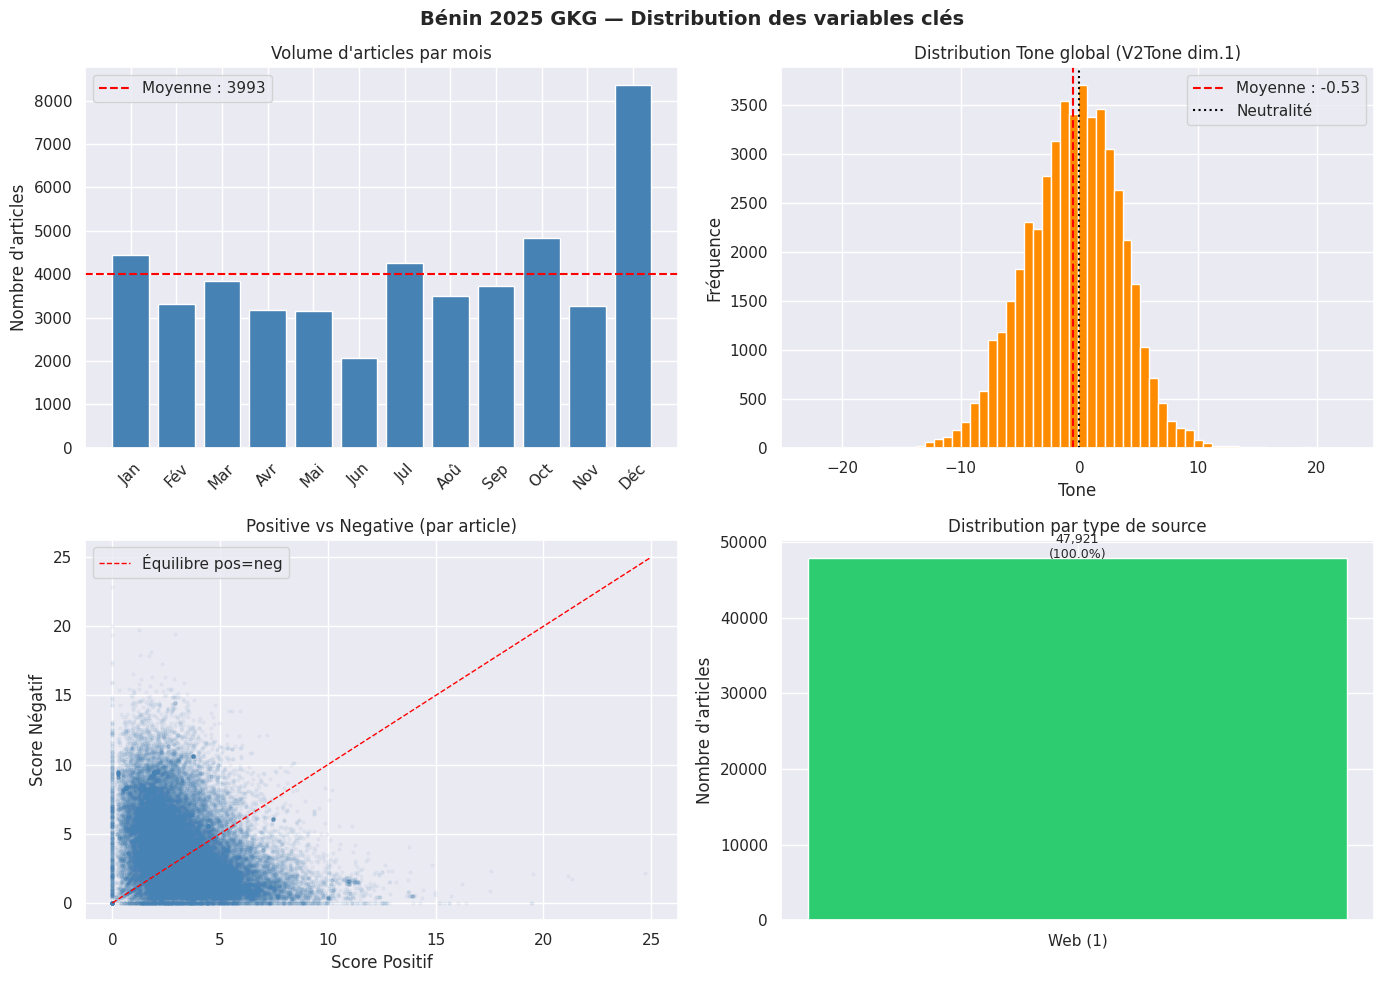

✅ Graphiques GKG Niveau 2 sauvegardés


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bénin 2025 GKG — Distribution des variables clés', fontsize=14, fontweight='bold')

# ── 1. Volume mensuel ──
volume_mensuel = df_gkg.groupby('mois').size().reset_index(name='nb_articles')
axes[0,0].bar(mois_labels, volume_mensuel['nb_articles'], color='steelblue')
axes[0,0].axhline(volume_mensuel['nb_articles'].mean(), color='red', linestyle='--',
                  label=f"Moyenne : {volume_mensuel['nb_articles'].mean():.0f}")
axes[0,0].set_title("Volume d'articles par mois")
axes[0,0].set_ylabel("Nombre d'articles")
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

# ── 2. Distribution Tone global ──
axes[0,1].hist(df_gkg['Tone'], bins=60, color='darkorange', edgecolor='white')
axes[0,1].axvline(df_gkg['Tone'].mean(), color='red', linestyle='--',
                  label=f"Moyenne : {df_gkg['Tone'].mean():.2f}")
axes[0,1].axvline(0, color='black', linestyle=':', label='Neutralité')
axes[0,1].set_title("Distribution Tone global (V2Tone dim.1)")
axes[0,1].set_xlabel("Tone")
axes[0,1].set_ylabel("Fréquence")
axes[0,1].legend()

# ── 3. Positive vs Negative ──
axes[1,0].scatter(df_gkg['Positive'], df_gkg['Negative'],
                  alpha=0.05, color='steelblue', s=5)
axes[1,0].plot([0, 25], [0, 25], color='red', linestyle='--',
               linewidth=1, label='Équilibre pos=neg')
axes[1,0].set_title("Positive vs Negative (par article)")
axes[1,0].set_xlabel("Score Positif")
axes[1,0].set_ylabel("Score Négatif")
axes[1,0].legend()

# ── 4. Distribution SourceCollectionIdentifier ──
source_counts = df_gkg['SourceCollectionIdentifier'].value_counts()
source_labels = {1: 'Web (1)', 2: 'Citation (2)', 3: 'Core (3)'}
axes[1,1].bar(
    [source_labels.get(k, str(k)) for k in source_counts.index],
    source_counts.values,
    color=['#2ecc71', '#3498db', '#e67e22']
)
axes[1,1].set_title("Distribution par type de source")
axes[1,1].set_ylabel("Nombre d'articles")
for i, v in enumerate(source_counts.values):
    axes[1,1].text(i, v + 50, f'{v:,}\n({v/len(df_gkg)*100:.1f}%)',
                   ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/data/raw/gkg_niveau2_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphiques GKG Niveau 2 sauvegardés")

#### Lecture du Niveau 2 GKG

##### Volume mensuel — Cohérence totale avec events
```
Même structure que la table events :
  Juin     : ~2 000 articles  ← creux confirmé dans les deux tables
  Décembre : ~8 200 articles  ← pic confirmé — le coup d'État capturé
  Moyenne  :  3 993 articles/mois
```
Les deux tables racontent la même histoire temporelle — c'est une validation croisée importante.

---

##### Tone global — Distribution plus propre qu'events
```
Moyenne  : -0.53  → moins négatif qu'events (-1.37)
Centré sur 0, quasi-symétrique
Queue gauche légèrement plus lourde → les extrêmes négatifs existent
```
GKG capture des articles plus nuancés qu'events. Un événement GDELT est une action brute — un article GKG contient du contexte, de l'analyse, ce qui tempère le ton.

---

##### Positive vs Negative — Le signal le plus révélateur

```
Masse principale sous la diagonale → Negative > Positive
pour la majorité des articles

Deux clusters visibles :
  1. Articles à faible score des deux  → couverture factuelle neutre
  2. Articles à Negative élevé (>5)    → couverture critique/alarmiste
     avec Positive proche de 0         → sans contrepartie positive

Très peu de points au-dessus de la diagonale → articles
franchement positifs sur le Bénin sont rares
```

---

##### Type de source — 100% Web
```
SourceCollectionIdentifier = 1 (Web) : 47 921 → 100%
```
Toute la couverture du Bénin en 2025 vient de sources web généralistes. Aucune source de citation académique ou Core. Ce n'est pas surprenant pour un pays de taille moyenne — mais ça dit que **l'image du Bénin est construite exclusivement par la presse en ligne**, sans couche académique ou institutionnelle.

---

##### Synthèse Niveau 2 GKG

```
3 confirmations par rapport à events :
  ✅ Même anomalie temporelle (juin creux, décembre pic)
  ✅ Ton légèrement négatif mais modéré
  ✅ La négativité domine structurellement

1 information nouvelle :
  ⚠️ Les articles franchement positifs sur le Bénin
     sont minoritaires — la presse ne célèbre pas
     le pays, elle le surveille
```